# Comparsion of the gradient boosting models
XGBoost, LightGBM, CatBoost

In [1042]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [1043]:
import sklearn
import xgboost as xgb

## Data preparation

In [1044]:
df = pd.read_csv('star_classification.csv')
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


### Removal of the categorical variables

In [1045]:
df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

In [1046]:
df = df.drop(columns=['obj_ID','run_ID','rerun_ID','cam_col','field_ID','spec_obj_ID','plate','MJD','fiber_ID'])

In [1047]:
df.columns

Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift'], dtype='str')

### Dealing with  Nans and duplicates 

In this dataset lack of data or duplicates are errors.

In [1048]:
df.dropna(inplace=True)

In [1049]:
df.drop_duplicates(inplace=True)

In [1050]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   alpha     100000 non-null  float64
 1   delta     100000 non-null  float64
 2   u         100000 non-null  float64
 3   g         100000 non-null  float64
 4   r         100000 non-null  float64
 5   i         100000 non-null  float64
 6   z         100000 non-null  float64
 7   class     100000 non-null  str    
 8   redshift  100000 non-null  float64
dtypes: float64(8), str(1)
memory usage: 6.9 MB


In [1051]:
print(df.duplicated().sum())

0


### Check the correction of target

<Axes: xlabel='class', ylabel='Count'>

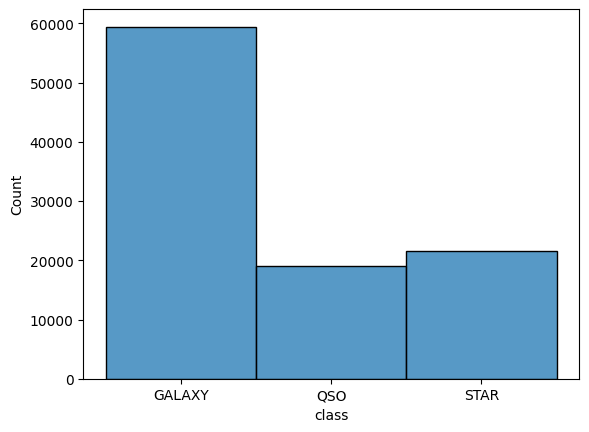

In [1052]:
sns.histplot(df['class'])

Data is too unbalanced. 
Records describing galaxies must be reduced.

Method 1:
Data removed randomly

In [1053]:
galaxies = df[df['class'] == 'GALAXY']

In [1054]:
galaxies_to_keep = galaxies.sample(n=40000, random_state=19)

Replace all galaxies from the original dataset with galaxies_to_keep

In [1055]:
df2 = df.drop(df[df['class'] == 'GALAXY'].index)

In [1056]:
df_random_galaxies = pd.concat([galaxies_to_keep, df2])

<Axes: xlabel='class', ylabel='Count'>

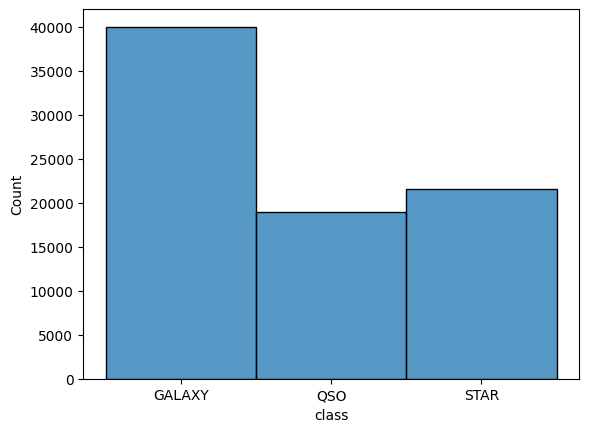

In [1057]:
sns.histplot(df_random_galaxies['class'])

Method 2:
Removal of the most common data in features.

None of the outliners will be missed.

Personally preferable.

In [1058]:
features1 = ['u', 'g', 'r', 'i', 'z']
features2 = ['alpha', 'delta']
features3 = ['redshift']

<Axes: >

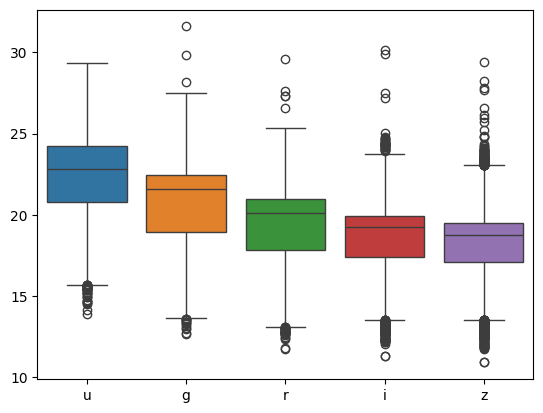

In [1059]:
sns.boxplot(data=df[df['class'] == 'GALAXY'][features1])

In [1060]:
features = features1 + features2 + features3

In [1061]:
mean_val = df[df['class'] == 'GALAXY' ] [features].mean()

In [1062]:
df['distance_from_mean'] = abs(df[df['class'] == 'GALAXY' ][features] - mean_val).sum(axis=1)

In [1063]:
df_common_galaxies = df.sort_values(by =  'distance_from_mean', ascending= False).iloc[19445:]

<Axes: xlabel='class', ylabel='Count'>

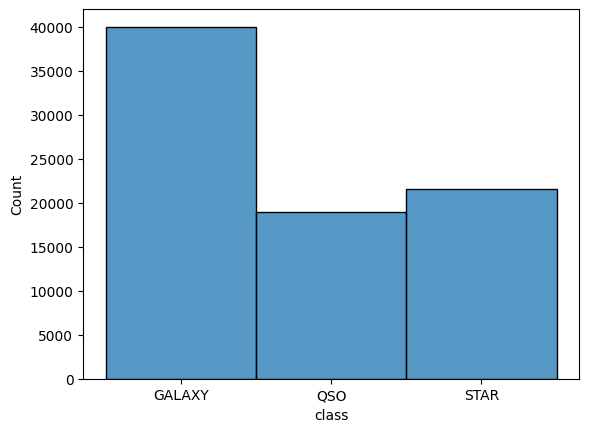

In [1064]:
sns.histplot(df_common_galaxies['class'])

In [1065]:
df_common_galaxies.drop(columns = ['distance_from_mean'], inplace = True)

Check if sets have the same size

In [1066]:
df_common_galaxies[df_common_galaxies['class'] == 'GALAXY'].count()

alpha       40000
delta       40000
u           40000
g           40000
r           40000
i           40000
z           40000
class       40000
redshift    40000
dtype: int64

In [1067]:
df_random_galaxies[df_random_galaxies['class'] == 'GALAXY'].count()

alpha       40000
delta       40000
u           40000
g           40000
r           40000
i           40000
z           40000
class       40000
redshift    40000
dtype: int64

### Comparison the data before and after removing galaxies

<Axes: >

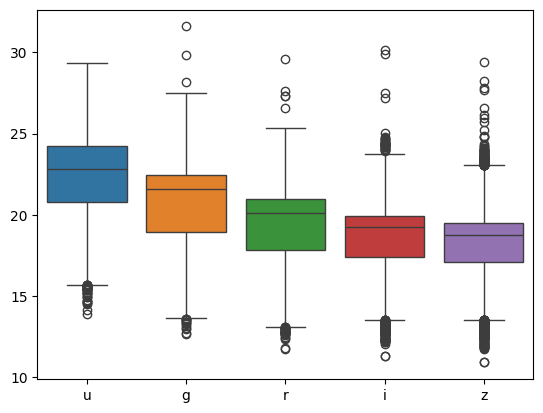

In [1068]:
sns.boxplot(df[df['class'] == 'GALAXY'][features1])

<Axes: >

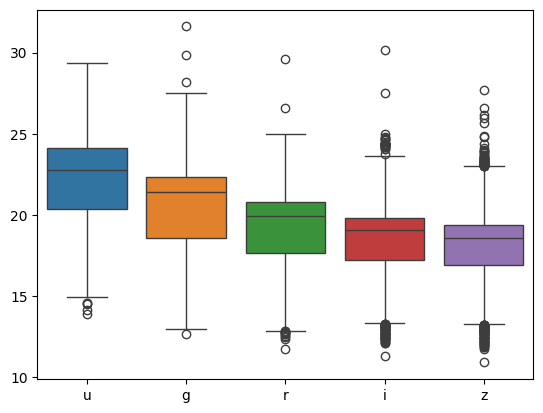

In [1069]:
sns.boxplot(df_common_galaxies[df_common_galaxies['class'] == 'GALAXY'][features1])

Removing the most common records did not significantly change the data - the approach can be used

<Axes: >

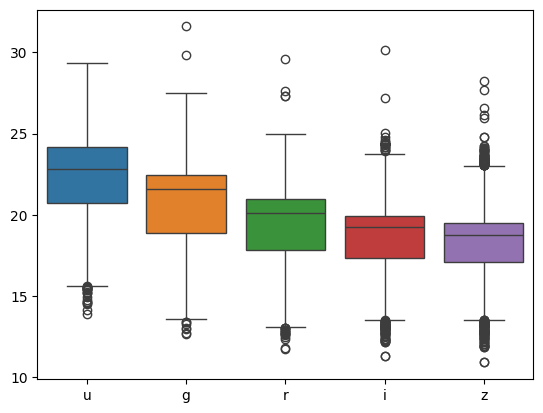

In [1070]:
sns.boxplot(df_random_galaxies[df_random_galaxies['class'] == 'GALAXY'] [features1])

Both approaches did not change its representativnes

### Check the correction of features

### Choose type of the data:

In [1071]:
df = df_common_galaxies

In [1072]:
#df = df_random_galaxies

### Correction for the STAR  & QSO type:

<Axes: >

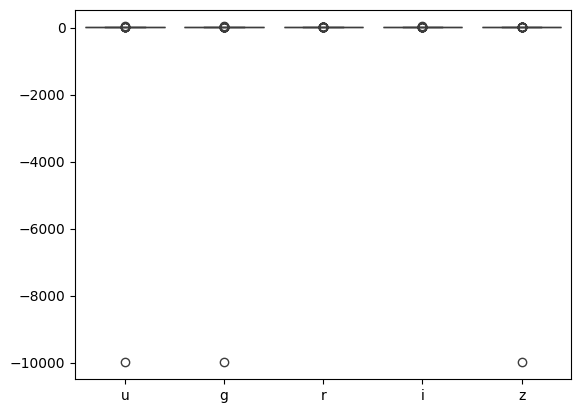

In [1073]:
sns.boxplot(df[df['class'] == 'STAR'][features1])

<Axes: >

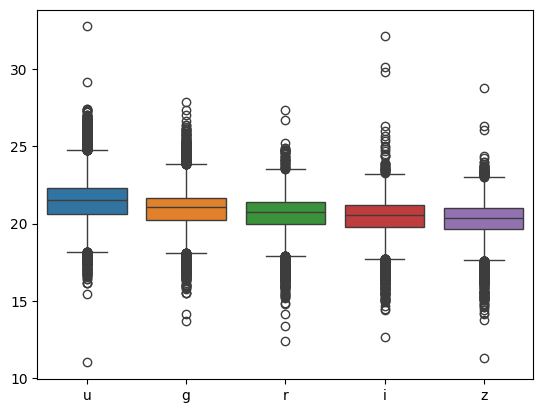

In [1074]:
sns.boxplot(df[df['class'] == 'QSO'][features1])

In [1075]:
df.sort_values(ascending= True, by = 'u')

,alpha,delta,u,g,r,i,z,class,redshift
79543,224.006526,-0.624304,-9999.00000,-9999.00000,18.16560,18.01675,-9999.00000,STAR,0.000089
57763,208.358688,33.825699,10.99623,13.66217,12.35763,12.63744,11.30247,QSO,3.955592
75784,239.473361,27.594369,12.10168,10.49820,10.11604,10.00865,10.44131,STAR,0.000008
4472,239.423127,28.548438,12.26240,10.51139,10.06854,13.41786,10.22551,STAR,0.000025
75620,239.207155,27.898444,12.30349,10.67180,10.19460,10.05509,10.65056,STAR,0.000003
...,...,...,...,...,...,...,...,...,...
1046,0.115997,22.714164,29.19901,25.35543,23.48086,21.56495,17.17135,QSO,0.253981
20225,19.689708,-1.058819,29.23438,25.40505,17.51251,16.55034,23.54460,STAR,-0.000167
19525,125.737753,33.875543,29.32565,20.29043,18.35283,17.85217,26.13011,GALAXY,0.503306
21245,22.566355,0.950467,30.66039,30.60700,29.37411,30.25009,16.82299,STAR,-0.000456


u, g, z equals -9999 is an error, has to be removed

In [1076]:
df.drop( df[df['u'] < 0].index, inplace = True)

In [1077]:
df.sort_values(ascending= True, by = 'u')

,alpha,delta,u,g,r,i,z,class,redshift
57763,208.358688,33.825699,10.99623,13.66217,12.35763,12.63744,11.30247,QSO,3.955592
75784,239.473361,27.594369,12.10168,10.49820,10.11604,10.00865,10.44131,STAR,0.000008
4472,239.423127,28.548438,12.26240,10.51139,10.06854,13.41786,10.22551,STAR,0.000025
75620,239.207155,27.898444,12.30349,10.67180,10.19460,10.05509,10.65056,STAR,0.000003
75583,239.702668,27.467439,12.99664,11.33897,10.98255,10.87374,11.19448,STAR,0.000174
...,...,...,...,...,...,...,...,...,...
1046,0.115997,22.714164,29.19901,25.35543,23.48086,21.56495,17.17135,QSO,0.253981
20225,19.689708,-1.058819,29.23438,25.40505,17.51251,16.55034,23.54460,STAR,-0.000167
19525,125.737753,33.875543,29.32565,20.29043,18.35283,17.85217,26.13011,GALAXY,0.503306
21245,22.566355,0.950467,30.66039,30.60700,29.37411,30.25009,16.82299,STAR,-0.000456


<Axes: >

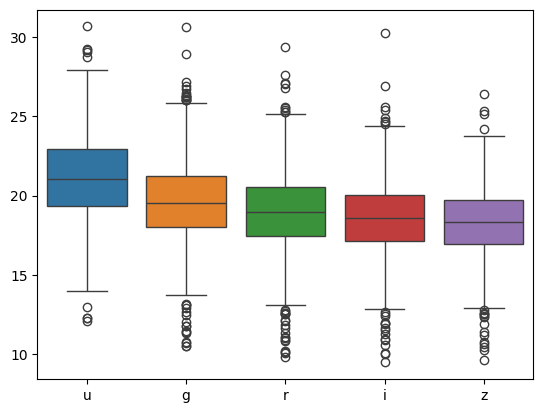

In [1078]:
sns.boxplot(df[df['class'] == 'STAR'][features1])

Galaxies, Stars and QSO's data is now correct.